# Hyperliquid follower fill-policy analysis

Decision notebook for the 0.5-2.5 second leader-to-venue regime. It compares the durable mainnet actions, bounded exchange fill extracts, and simultaneous BBO/L2 captures. The objective is not minimum quoted slippage in isolation: safety and terminal exchange truth come first, then target-tracking error, fill probability inside a hard economic boundary, fees, and action count.


In [1]:
from __future__ import annotations

import bisect
import json
import math
import os
import sqlite3
import statistics
from collections import Counter, defaultdict
from pathlib import Path
from IPython.display import Markdown, SVG, display

START = Path.cwd().resolve()
ROOT = next((path for path in (START, *START.parents) if (path / 'pyproject.toml').exists()), START)
AUDIT = ROOT / 'audit' / 'fill_quality'
ENGINE_ROOT = (Path(os.environ['LOCALAPPDATA']) / 'HyperliquidCopytrader' / 'runtime' / 'continuous-ui' / 'engines' / 'mainnet')
ENGINES = ('continuous-ten-mainnet-v2', 'continuous-ten-mainnet-v3')
TERMINAL = {'NOT_SENT', 'REJECTED', 'PARTIALLY_FILLED', 'FILLED', 'CANCELED'}
FILLED = {'PARTIALLY_FILLED', 'FILLED'}

def percentile(values, q):
    values = sorted(float(v) for v in values)
    if not values:
        return math.nan
    index = (len(values) - 1) * q
    lo, hi = math.floor(index), math.ceil(index)
    if lo == hi:
        return values[lo]
    return values[lo] * (hi - index) + values[hi] * (index - lo)

def markdown_table(headers, rows):
    lines = ['| ' + ' | '.join(headers) + ' |', '| ' + ' | '.join(['---'] * len(headers)) + ' |']
    lines.extend('| ' + ' | '.join(str(cell) for cell in row) + ' |' for row in rows)
    return '\n'.join(lines)

def horizontal_bars(rows, *, title, width=820, bar_width=430):
    height = 62 + 34 * len(rows)
    maximum = max((float(value) for _, value in rows), default=1) or 1
    parts = [f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">', '<style>text{font-family:Segoe UI,Arial,sans-serif;fill:#18202a}.title{font-weight:700;font-size:18px}.label{font-size:13px}.value{font-size:12px;fill:#445}</style>', f'<text x="12" y="25" class="title">{title}</text>']
    for index, (label, value) in enumerate(rows):
        y = 48 + index * 34
        length = max(1, float(value) / maximum * bar_width)
        parts.append(f'<text x="12" y="{y + 15}" class="label">{label}</text>')
        parts.append(f'<rect x="210" y="{y}" width="{length:.1f}" height="20" rx="3" fill="#2f6fed"/>')
        parts.append(f'<text x="{220 + length:.1f}" y="{y + 15}" class="value">{float(value):.2f}</text>')
    parts.append('</svg>')
    return ''.join(parts)

print('Repository:', ROOT)
print('Analysis sources:', AUDIT)


Repository: C:\Users\papaa\OneDrive\Документы\copytradehyperliquid\hyperliquid-copytrader
Analysis sources: C:\Users\papaa\OneDrive\Документы\copytradehyperliquid\hyperliquid-copytrader\audit\fill_quality


## Durable action history and data quality

Only non-secret action fields are read. Signed payloads and API-wallet material are deliberately excluded. CLOID is the deduplication key across engine generations.


In [2]:
actions_by_cloid = {}
for engine in ENGINES:
    for db_path in sorted((ENGINE_ROOT / engine / 'actions').glob('*.sqlite3')):
        slot = db_path.stem
        with sqlite3.connect(db_path) as db:
            db.row_factory = sqlite3.Row
            rows = db.execute('SELECT cloid, desired_id, market, attempt_no, requested_size, cumulative_filled_size, action_json, state, outcome_detail, created_ms, send_attempted_ms, terminal_ms FROM actions').fetchall()
        for row in rows:
            wire = json.loads(row['action_json'])['orders'][0]
            item = {
                'engine': engine, 'slot': slot, 'cloid': row['cloid'], 'desired_id': row['desired_id'],
                'market': row['market'], 'attempt_no': int(row['attempt_no']),
                'requested_size': float(row['requested_size']), 'filled_size': float(row['cumulative_filled_size']),
                'side': 'buy' if wire['b'] else 'sell', 'reduce_only': bool(wire['r']),
                'limit_px': float(wire['p']), 'state': row['state'],
                'outcome_detail': row['outcome_detail'] or '', 'created_ms': int(row['created_ms']),
                'send_attempted_ms': row['send_attempted_ms'], 'terminal_ms': row['terminal_ms'],
            }
            prior = actions_by_cloid.get(item['cloid'])
            if prior is None or item['created_ms'] > prior['created_ms']:
                actions_by_cloid[item['cloid']] = item
actions = sorted(actions_by_cloid.values(), key=lambda item: (item['created_ms'], item['cloid']))
assert len(actions) == len({item['cloid'] for item in actions}), 'duplicate CLOID after deduplication'
assert all(item['state'] in TERMINAL for item in actions), 'nonterminal durable action in analysis population'
assert len(actions) >= 250, 'durable action population unexpectedly small'

state_counts = Counter(item['state'] for item in actions)
latencies = [item['terminal_ms'] - item['send_attempted_ms'] for item in actions if item['terminal_ms'] and item['send_attempted_ms']]
groups = defaultdict(list)
for item in actions:
    groups[(item['slot'], item['market'], item['desired_id'])].append(item)
repeated = [rows for rows in groups.values() if len(rows) > 1]
extra_attempts = sum(len(rows) - 1 for rows in repeated)
eventual_repeated_fills = sum(any(row['state'] in FILLED for row in rows) for rows in repeated)
no_liquidity = [item for item in actions if 'could not immediately match' in item['outcome_detail'].lower() or 'no liquidity' in item['outcome_detail'].lower()]
server_failures = [item for item in actions if 'server_error_response' in item['outcome_detail'].lower() or 'top_level_error' in item['outcome_detail'].lower()]

summary_rows = [
    ('Unique terminal actions', len(actions)),
    ('Filled', state_counts['FILLED']),
    ('Partially filled', state_counts['PARTIALLY_FILLED']),
    ('Rejected', state_counts['REJECTED']),
    ('Explicit IOC no-liquidity', len(no_liquidity)),
    ('Server/top-level failures', len(server_failures)),
    ('Desired groups with retries', len(repeated)),
    ('Attempts beyond first', extra_attempts),
    ('Retried groups eventually filled', f'{eventual_repeated_fills}/{len(repeated)}'),
    ('Send-to-terminal p50 ms', f'{percentile(latencies, .50):.1f}'),
    ('Send-to-terminal p95 ms', f'{percentile(latencies, .95):.1f}'),
]
display(Markdown(markdown_table(['Measure', 'Observed'], summary_rows)))


| Measure | Observed |
| --- | --- |
| Unique terminal actions | 272 |
| Filled | 192 |
| Partially filled | 1 |
| Rejected | 79 |
| Explicit IOC no-liquidity | 49 |
| Server/top-level failures | 25 |
| Desired groups with retries | 17 |
| Attempts beyond first | 39 |
| Retried groups eventually filled | 7/17 |
| Send-to-terminal p50 ms | 940.0 |
| Send-to-terminal p95 ms | 1051.3 |

| Market | Actions | Fill/partial | Rate % |
| --- | --- | --- | --- |
| CASHCAT | 73 | 37 | 50.7 |
| xyz:CL | 54 | 41 | 75.9 |
| xyz:CXMT | 35 | 26 | 74.3 |
| PUMP | 25 | 17 | 68.0 |
| xyz:BRENTOIL | 11 | 2 | 18.2 |
| xyz:SKHX | 8 | 8 | 100.0 |
| xyz:SMSN | 8 | 7 | 87.5 |
| ONDO | 7 | 7 | 100.0 |
| WLD | 7 | 7 | 100.0 |
| GRAM | 6 | 6 | 100.0 |
| HYPE | 6 | 6 | 100.0 |
| LIT | 6 | 6 | 100.0 |

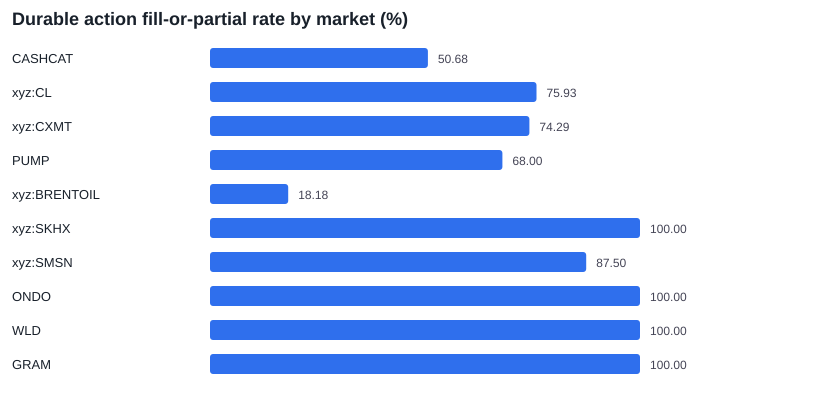

In [3]:
market_rows = []
for market, rows in sorted(defaultdict(list, {m: [a for a in actions if a['market'] == m] for m in {a['market'] for a in actions}}).items()):
    filled = sum(row['state'] in FILLED for row in rows)
    market_rows.append((market, len(rows), filled, 100 * filled / len(rows)))
market_rows.sort(key=lambda row: (-row[1], row[0]))
display(Markdown(markdown_table(['Market', 'Actions', 'Fill/partial', 'Rate %'], [(m, n, f, f'{r:.1f}') for m, n, f, r in market_rows[:12]])))
display(SVG(horizontal_bars([(m, r) for m, n, f, r in market_rows[:10]], title='Durable action fill-or-partial rate by market (%)')))


## Leader-relative price quality

Follower fills are joined by durable CLOID. Leader fills are matched within the same slot, market, and side to the nearest preceding fill inside ten seconds. This is an explicit heuristic because older journals did not retain the causal leader fill identity.


In [4]:
follower_extract = json.loads((AUDIT / 'exchange_follower_fills.json').read_text(encoding='utf-8'))
leader_extract = json.loads((AUDIT / 'exchange_leader_fills.json').read_text(encoding='utf-8'))

follower_fills = defaultdict(list)
for query in follower_extract['queries']:
    for fill in query.get('fills', []):
        if fill.get('cloid'):
            follower_fills[str(fill['cloid']).lower()].append(fill)
leader_fills = defaultdict(list)
for query in leader_extract['queries']:
    slot = query.get('slot') or (query.get('slots') or [None])[0]
    if slot:
        leader_fills[slot].extend(query.get('fills', []))
for rows in leader_fills.values():
    rows.sort(key=lambda row: int(row['time']))

matched = []
for action in actions:
    if action['reduce_only']:
        continue
    candidates = [fill for fill in leader_fills[action['slot']] if fill['coin'] == action['market'] and (('B' if action['side'] == 'buy' else 'A') == fill['side']) and 0 <= action['created_ms'] - int(fill['time']) <= 10_000]
    if not candidates:
        continue
    leader = min(candidates, key=lambda fill: action['created_ms'] - int(fill['time']))
    leader_px = float(leader['px'])
    headroom = ((action['limit_px'] / leader_px - 1) if action['side'] == 'buy' else (1 - action['limit_px'] / leader_px)) * 10_000
    follower_rows = follower_fills.get(action['cloid'].lower(), [])
    fill_px = None
    if follower_rows:
        total = sum(float(row['sz']) for row in follower_rows)
        fill_px = sum(float(row['px']) * float(row['sz']) for row in follower_rows) / total
    adverse = None if fill_px is None else ((fill_px / leader_px - 1) if action['side'] == 'buy' else (1 - fill_px / leader_px)) * 10_000
    matched.append({**action, 'leader_px': leader_px, 'headroom_bps': headroom, 'adverse_fill_bps': adverse, 'leader_age_ms': action['created_ms'] - int(leader['time'])})

adverse = [row['adverse_fill_bps'] for row in matched if row['adverse_fill_bps'] is not None]
nonserver = [row for row in matched if 'server_error_response' not in row['outcome_detail'].lower() and 'top_level_error' not in row['outcome_detail'].lower()]
bins = [(-math.inf, 0, '<=0'), (0, 10, '0-10'), (10, 20, '10-20'), (20, 25, '20-25'), (25, 35, '25-35'), (35, 50, '35-50'), (50, math.inf, '>50')]
bin_rows = []
for low, high, label in bins:
    rows = [row for row in nonserver if low < row['headroom_bps'] <= high]
    if rows:
        filled = sum(row['state'] in FILLED for row in rows)
        bin_rows.append((label, len(rows), filled, 100 * filled / len(rows)))
price_rows = [
    ('Matched filled entries', len(adverse)),
    ('Adverse fill p50 bps', f'{percentile(adverse, .50):.2f}'),
    ('Adverse fill p90 bps', f'{percentile(adverse, .90):.2f}'),
    ('Adverse fill p95 bps', f'{percentile(adverse, .95):.2f}'),
    ('Filled entries above 50 bps', sum(value > 50 for value in adverse)),
]
display(Markdown(markdown_table(['Measure', 'Observed'], price_rows)))
display(Markdown(markdown_table(['Leader-relative limit headroom', 'N', 'Filled', 'Rate %'], [(label, n, f, f'{rate:.1f}') for label, n, f, rate in bin_rows])))


| Measure | Observed |
| --- | --- |
| Matched filled entries | 78 |
| Adverse fill p50 bps | 0.81 |
| Adverse fill p90 bps | 17.86 |
| Adverse fill p95 bps | 25.88 |
| Filled entries above 50 bps | 3 |

| Leader-relative limit headroom | N | Filled | Rate % |
| --- | --- | --- | --- |
| <=0 | 17 | 1 | 5.9 |
| 0-10 | 7 | 2 | 28.6 |
| 10-20 | 15 | 12 | 80.0 |
| 20-25 | 25 | 21 | 84.0 |
| 25-35 | 33 | 31 | 93.9 |
| 35-50 | 7 | 7 | 100.0 |
| >50 | 4 | 4 | 100.0 |

## Live BBO/L2 evidence and latency sensitivity

The five-minute capture measures spread and coarse depth. The simultaneous 90-second capture compares change-driven BBO cadence with periodic L2 cadence and replays adverse quote movement over 0.5, 0.94, and 2.5 seconds. Because BBO is change-driven, a quiet quote is state, not missing data, while the connection remains continuous.


In [5]:
def read_jsonl(path):
    return [json.loads(line) for line in path.read_text(encoding='utf-8').splitlines() if line.strip()]

books_capture = read_jsonl(AUDIT / 'live_books_5m.jsonl')
bbo_capture = read_jsonl(AUDIT / 'live_bbo_90s.jsonl')
l2_rows = []
for frame in books_capture:
    if frame.get('channel') != 'l2Book':
        continue
    data = frame['data']; bids, asks = data['levels']
    bid, ask = float(bids[0]['px']), float(asks[0]['px'])
    midpoint = (bid + ask) / 2
    l2_rows.append({'market': data['coin'], 'time': int(data['time']), 'bid': bid, 'ask': ask, 'spread_bps': (ask - bid) / midpoint * 10_000, 'top_bid_notional': bid * float(bids[0]['sz']), 'top_ask_notional': ask * float(asks[0]['sz'])})
assert l2_rows, 'empty L2 capture'

feed_times = defaultdict(list)
bbo_states = defaultdict(list)
for frame in bbo_capture:
    channel, data = frame.get('channel'), frame.get('data', {})
    if not isinstance(data, dict):
        continue
    market = data.get('coin')
    if channel in {'bbo', 'l2Book', 'activeAssetCtx'} and market:
        feed_times[(channel, market)].append(int(frame['received_wall_ns']) / 1_000_000)
    if channel == 'bbo' and market and isinstance(data.get('bbo'), list) and data['bbo'][0] and data['bbo'][1]:
        bbo_states[market].append((int(data['time']), float(data['bbo'][0]['px']), float(data['bbo'][1]['px'])))
assert bbo_states, 'empty BBO capture'
cadence_rows = []
for (channel, market), times in sorted(feed_times.items()):
    intervals = [right - left for left, right in zip(times, times[1:]) if right >= left]
    if intervals:
        cadence_rows.append((channel, market, len(times), percentile(intervals, .50)))

spread_rows = []
for market in sorted({row['market'] for row in l2_rows}):
    rows = [row for row in l2_rows if row['market'] == market]
    spread_rows.append((market, len(rows), percentile([row['spread_bps'] for row in rows], .50), percentile([row['spread_bps'] for row in rows], .95), percentile([min(row['top_bid_notional'], row['top_ask_notional']) for row in rows], .10)))
display(Markdown(markdown_table(['Market', 'L2 N', 'Spread p50 bps', 'Spread p95 bps', 'Top notional p10 USD'], [(m, n, f'{p50:.2f}', f'{p95:.2f}', f'{top:.1f}') for m, n, p50, p95, top in spread_rows])))
display(Markdown(markdown_table(['Feed', 'Market', 'Events', 'Median interval ms'], [(c, m, n, f'{ms:.0f}') for c, m, n, ms in cadence_rows])))


| Market | L2 N | Spread p50 bps | Spread p95 bps | Top notional p10 USD |
| --- | --- | --- | --- | --- |
| BTC | 57 | 0.15 | 0.15 | 2438.5 |
| CASHCAT | 57 | 33.52 | 80.38 | 16.5 |
| xyz:CL | 57 | 0.47 | 1.43 | 100.0 |
| xyz:CXMT | 57 | 17.90 | 28.95 | 67.3 |
| xyz:KR200 | 57 | 13.24 | 30.28 | 31.5 |

| Feed | Market | Events | Median interval ms |
| --- | --- | --- | --- |
| bbo | BTC | 584 | 109 |
| bbo | CASHCAT | 205 | 278 |
| bbo | xyz:CL | 455 | 126 |
| bbo | xyz:CXMT | 238 | 299 |
| bbo | xyz:KR200 | 11 | 885 |
| l2Book | BTC | 17 | 5365 |
| l2Book | CASHCAT | 17 | 5369 |
| l2Book | xyz:CL | 17 | 5368 |
| l2Book | xyz:CXMT | 17 | 5368 |
| l2Book | xyz:KR200 | 17 | 5368 |

| Horizon ms | Market | Directional observations | Adverse move p95 bps | Maximum bps |
| --- | --- | --- | --- | --- |
| 500 | BTC | 1158 | 0.00 | 0.90 |
| 500 | CASHCAT | 406 | 0.16 | 42.74 |
| 500 | xyz:CL | 906 | 1.17 | 2.80 |
| 500 | xyz:CXMT | 472 | 0.29 | 10.18 |
| 500 | xyz:KR200 | 18 | 0.00 | 0.00 |
| 940 | BTC | 1152 | 0.15 | 0.90 |
| 940 | CASHCAT | 406 | 0.31 | 42.74 |
| 940 | xyz:CL | 904 | 1.29 | 5.49 |
| 940 | xyz:CXMT | 470 | 0.29 | 10.04 |
| 940 | xyz:KR200 | 18 | 0.00 | 0.00 |
| 2500 | BTC | 1134 | 0.45 | 0.90 |
| 2500 | CASHCAT | 394 | 15.46 | 64.90 |
| 2500 | xyz:CL | 904 | 2.69 | 5.49 |
| 2500 | xyz:CXMT | 460 | 1.21 | 10.04 |
| 2500 | xyz:KR200 | 14 | 0.00 | 0.00 |

| Horizon ms | Market | Buffer bps | Observed coverage % | N |
| --- | --- | --- | --- | --- |
| 940 | BTC | 25 | 100.0 | 1152 |
| 940 | BTC | 50 | 100.0 | 1152 |
| 940 | BTC | 100 | 100.0 | 1152 |
| 940 | CASHCAT | 25 | 99.0 | 406 |
| 940 | CASHCAT | 50 | 100.0 | 406 |
| 940 | CASHCAT | 100 | 100.0 | 406 |
| 940 | xyz:CL | 25 | 100.0 | 904 |
| 940 | xyz:CL | 50 | 100.0 | 904 |
| 940 | xyz:CL | 100 | 100.0 | 904 |
| 940 | xyz:CXMT | 25 | 100.0 | 470 |
| 940 | xyz:CXMT | 50 | 100.0 | 470 |
| 940 | xyz:CXMT | 100 | 100.0 | 470 |
| 940 | xyz:KR200 | 25 | 100.0 | 18 |
| 940 | xyz:KR200 | 50 | 100.0 | 18 |
| 940 | xyz:KR200 | 100 | 100.0 | 18 |
| 2500 | BTC | 25 | 100.0 | 1134 |
| 2500 | BTC | 50 | 100.0 | 1134 |
| 2500 | BTC | 100 | 100.0 | 1134 |
| 2500 | CASHCAT | 25 | 97.7 | 394 |
| 2500 | CASHCAT | 50 | 99.5 | 394 |
| 2500 | CASHCAT | 100 | 100.0 | 394 |
| 2500 | xyz:CL | 25 | 100.0 | 904 |
| 2500 | xyz:CL | 50 | 100.0 | 904 |
| 2500 | xyz:CL | 100 | 100.0 | 904 |
| 2500 | xyz:CXMT | 25 | 100.0 | 460 |
| 2500 | xyz:CXMT | 50 | 100.0 | 460 |
| 2500 | xyz:CXMT | 100 | 100.0 | 460 |
| 2500 | xyz:KR200 | 25 | 100.0 | 14 |
| 2500 | xyz:KR200 | 50 | 100.0 | 14 |
| 2500 | xyz:KR200 | 100 | 100.0 | 14 |

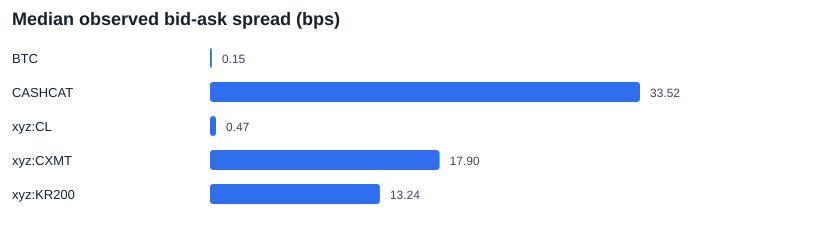

In [6]:
movement_rows = []
coverage_rows = []
for horizon in (500, 940, 2500):
    for market, states in sorted(bbo_states.items()):
        times = [row[0] for row in states]
        adverse_moves = []
        for time_ms, bid, ask in states:
            target = time_ms + horizon
            if target > times[-1]:
                continue
            index = bisect.bisect_right(times, target) - 1
            future_bid, future_ask = states[index][1], states[index][2]
            adverse_moves.extend((max(0.0, (future_ask / ask - 1) * 10_000), max(0.0, (1 - future_bid / bid) * 10_000)))
        if not adverse_moves:
            continue
        movement_rows.append((horizon, market, len(adverse_moves), percentile(adverse_moves, .95), max(adverse_moves)))
        for buffer in (25, 50, 100):
            coverage_rows.append((horizon, market, buffer, 100 * sum(move <= buffer for move in adverse_moves) / len(adverse_moves), len(adverse_moves)))
display(Markdown(markdown_table(['Horizon ms', 'Market', 'Directional observations', 'Adverse move p95 bps', 'Maximum bps'], [(h, m, n, f'{p95:.2f}', f'{maximum:.2f}') for h, m, n, p95, maximum in movement_rows])))
display(Markdown(markdown_table(['Horizon ms', 'Market', 'Buffer bps', 'Observed coverage %', 'N'], [(h, m, b, f'{coverage:.1f}', n) for h, m, b, coverage, n in coverage_rows if h in {940, 2500}])))
display(SVG(horizontal_bars([(market, p50) for market, n, p50, p95, top in spread_rows], title='Median observed bid-ask spread (bps)')))


## Policy tournament

An aggressive IOC limit is a worst acceptable price, not the price paid. Therefore, once a 50-bps leader-relative boundary is accepted, placing the entry limit at that boundary weakly dominates any narrower limit: the two receive the same resting prices when both fill, while the boundary order also fills liquidity that remains economically permitted. A BBO-relative buffer without a leader cap can instead chase after an already adverse move.


In [7]:
policy_rows = [
    ('Mark/mid + 25 bps; shrink to visible L2', 'Reject', 'Can sit behind a wide live ask/bid; stale L2 can turn a valid full order into a subminimum child.'),
    ('Latest BBO + fixed buffer only', 'Adapt', 'Good generic market-order baseline, but must not chase beyond the leader-relative economic boundary.'),
    ('Latest BBO + 50-bps leader hard cap; full IOC', 'Adopt', 'Best entry policy for current scale: current marketability, bounded economics, venue-native partial fill, persistent latest target.'),
    ('Reduce-only BBO + 100 bps', 'Adopt', 'Unwanted exposure has a different loss function; observed reductions already fill far more reliably than entries.'),
    ('Emergency reduce-only BBO + 300 bps', 'Adopt', 'Explicitly wider risk-removal policy, never shared with normal entry.'),
    ('Maker-first / UI Chase', 'Reject as default', 'Saves about 3 bps versus taker but adds queue uncertainty plus cancel/reprice commit cycles to an already delayed signal.'),
    ('Native TWAP', 'Reject', 'Thirty-second slicing and a venue-wide 3% envelope solve large persistent parent orders, not rapidly changing canary targets.'),
    ('Per-market concurrent actions', 'Defer', 'No current evidence that cross-market blocking justifies added nonce, margin-reservation, and UNKNOWN-state complexity.'),
]
display(Markdown(markdown_table(['Candidate', 'Decision', 'Evidence-based reason'], policy_rows)))


| Candidate | Decision | Evidence-based reason |
| --- | --- | --- |
| Mark/mid + 25 bps; shrink to visible L2 | Reject | Can sit behind a wide live ask/bid; stale L2 can turn a valid full order into a subminimum child. |
| Latest BBO + fixed buffer only | Adapt | Good generic market-order baseline, but must not chase beyond the leader-relative economic boundary. |
| Latest BBO + 50-bps leader hard cap; full IOC | Adopt | Best entry policy for current scale: current marketability, bounded economics, venue-native partial fill, persistent latest target. |
| Reduce-only BBO + 100 bps | Adopt | Unwanted exposure has a different loss function; observed reductions already fill far more reliably than entries. |
| Emergency reduce-only BBO + 300 bps | Adopt | Explicitly wider risk-removal policy, never shared with normal entry. |
| Maker-first / UI Chase | Reject as default | Saves about 3 bps versus taker but adds queue uncertainty plus cancel/reprice commit cycles to an already delayed signal. |
| Native TWAP | Reject | Thirty-second slicing and a venue-wide 3% envelope solve large persistent parent orders, not rapidly changing canary targets. |
| Per-market concurrent actions | Defer | No current evidence that cross-market blocking justifies added nonce, margin-reservation, and UNKNOWN-state complexity. |

## Decision and uncertainty

**Selected policy:** fresh fills create durable latest targets; entries use the latest BBO for marketability and the leader fill plus 50 bps as the hard adverse limit; normal reductions use reduce-only BBO plus 100 bps; emergency reductions use reduce-only BBO plus 300 bps. Submit the full risk-approved IOC, fold terminal fills exactly once, and replan a partial/no-fill only after a newer source revision or meaningful post-result liquidity evidence. Unchanged periodic L2 snapshots use bounded 1/2/5-second retry backoff, one-sided books retain their executable reduction side, and each slot keeps one unresolved action.

The 50/100/300-bps values are launch settings, not timeless optima. The historical leader match is heuristic; the live capture is short; BBO snapshots cannot prove queue behavior; and maker/chase cannot be simulated fairly without queue-position data. The new action metrics therefore retain the leader trigger, BBO/L2 evidence, policy class, submitted/visible size, fill price, and order ID so post-change calibration can use causal evidence instead of another speculative policy rewrite.
